# Genre Classification with MLPs
Comparing three approaches: Baseline MLP, Class-Balanced MLP, and SMOTE MLP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE

## 1. Load and Preprocess Data

In [2]:
print("Loading dataset...")
data = pd.read_csv("../../data/processed/final_dataset.csv")

# Define features
feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness'
]

# Remove samples with NaN values
df = data.dropna(subset=feature_cols)

# Filter to specific genres
keep_genres = ['Acoustic', 'Electronic', 'Hip-Hop', 'Latin', 'Metal']
df = df[df['macro_genre'].isin(keep_genres)]

X = df[feature_cols].values
y_raw = df['macro_genre'].values

print(f"Dataset shape after filtering: {df.shape}")

# Encode string labels to integers
print("Encoding target labels...")
le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_
print(f"Classes encoded: {class_names}")

Loading dataset...
Dataset shape after filtering: (685567, 15)
Encoding target labels...
Classes encoded: ['Acoustic' 'Electronic' 'Hip-Hop' 'Latin' 'Metal']


## 2. Train/Test Split

In [3]:
n = len(X)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

split = int(0.8 * n)
train_idx, test_idx = idx[:split], idx[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique), counts):
    print(f"  {cls}: {cnt}")

Training set size: 548453
Test set size: 137114

Class distribution in training set:
  Acoustic: 130812
  Electronic: 188597
  Hip-Hop: 21700
  Latin: 85710
  Metal: 121634


## 3. Feature Scaling

In [4]:
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

Scaling features...
Scaling complete!


## 4. Baseline MLP (No Balancing)

In [5]:
print("=" * 60)
print("Training Baseline MLP (No Class Balancing)")
print("=" * 60)

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

mlp_baseline.fit(X_train_scaled, y_train)
print("\nBaseline training complete!")

Training Baseline MLP (No Class Balancing)
Iteration 1, loss = 0.76294619
Validation score: 0.726270
Iteration 2, loss = 0.73213582
Validation score: 0.731485
Iteration 3, loss = 0.72507748
Validation score: 0.730609
Iteration 4, loss = 0.72024548
Validation score: 0.733818
Iteration 5, loss = 0.71653901
Validation score: 0.733162
Iteration 6, loss = 0.71486123
Validation score: 0.736006
Iteration 7, loss = 0.71278027
Validation score: 0.734001
Iteration 8, loss = 0.71076097
Validation score: 0.735879
Iteration 9, loss = 0.70940875
Validation score: 0.735259
Iteration 10, loss = 0.70783757
Validation score: 0.734858
Iteration 11, loss = 0.70660476
Validation score: 0.739142
Iteration 12, loss = 0.70547467
Validation score: 0.737520
Iteration 13, loss = 0.70455184
Validation score: 0.737447
Iteration 14, loss = 0.70370117
Validation score: 0.737957
Iteration 15, loss = 0.70264217
Validation score: 0.738212
Iteration 16, loss = 0.70197517
Validation score: 0.739598
Iteration 17, loss = 0

In [6]:
# Evaluate Baseline MLP
y_pred_baseline = mlp_baseline.predict(X_test_scaled)
y_test_labels = le.inverse_transform(y_test)
y_pred_baseline_labels = le.inverse_transform(y_pred_baseline)

acc_baseline = accuracy_score(y_test_labels, y_pred_baseline_labels)
f1_baseline = f1_score(y_test_labels, y_pred_baseline_labels, average='macro')

print(f"\n{'Baseline MLP Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc_baseline:.2%}")
print(f"F1 Score (macro): {f1_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_baseline_labels))


                    Baseline MLP Results                    
Accuracy: 74.50%
F1 Score (macro): 0.6616

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.80      0.77      0.78     32730
  Electronic       0.72      0.81      0.76     47171
     Hip-Hop       0.45      0.21      0.29      5288
       Latin       0.74      0.71      0.73     21562
       Metal       0.76      0.74      0.75     30363

    accuracy                           0.74    137114
   macro avg       0.69      0.65      0.66    137114
weighted avg       0.74      0.74      0.74    137114



## 5. Class-Balanced MLP

In [7]:
print("\n" + "=" * 60)
print("Training Class-Balanced MLP")
print("=" * 60)

# Compute class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

mlp_balanced = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

# Note: MLPClassifier doesn't have class_weight parameter
# We'll use sample_weight in fit instead
sample_weights = np.array([class_weight_dict[label] for label in y_train])
mlp_balanced.fit(X_train_scaled, y_train)
print("\nClass-balanced training complete!")


Training Class-Balanced MLP
Class weights: {0: np.float64(0.8385362199186619), 1: np.float64(0.58161370541419), 2: np.float64(5.054866359447004), 3: np.float64(1.2797876560494692), 4: np.float64(0.9018087048029334)}
Iteration 1, loss = 0.76294619
Validation score: 0.726270
Iteration 2, loss = 0.73213582
Validation score: 0.731485
Iteration 3, loss = 0.72507748
Validation score: 0.730609
Iteration 4, loss = 0.72024548
Validation score: 0.733818
Iteration 5, loss = 0.71653901
Validation score: 0.733162
Iteration 6, loss = 0.71486123
Validation score: 0.736006
Iteration 7, loss = 0.71278027
Validation score: 0.734001
Iteration 8, loss = 0.71076097
Validation score: 0.735879
Iteration 9, loss = 0.70940875
Validation score: 0.735259
Iteration 10, loss = 0.70783757
Validation score: 0.734858
Iteration 11, loss = 0.70660476
Validation score: 0.739142
Iteration 12, loss = 0.70547467
Validation score: 0.737520
Iteration 13, loss = 0.70455184
Validation score: 0.737447
Iteration 14, loss = 0.70

In [8]:
# Evaluate Class-Balanced MLP
y_pred_balanced = mlp_balanced.predict(X_test_scaled)
y_pred_balanced_labels = le.inverse_transform(y_pred_balanced)

acc_balanced = accuracy_score(y_test_labels, y_pred_balanced_labels)
f1_balanced = f1_score(y_test_labels, y_pred_balanced_labels, average='macro')

print(f"\n{'Class-Balanced MLP Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc_balanced:.2%}")
print(f"F1 Score (macro): {f1_balanced:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_balanced_labels))


                 Class-Balanced MLP Results                 
Accuracy: 74.50%
F1 Score (macro): 0.6616

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.80      0.77      0.78     32730
  Electronic       0.72      0.81      0.76     47171
     Hip-Hop       0.45      0.21      0.29      5288
       Latin       0.74      0.71      0.73     21562
       Metal       0.76      0.74      0.75     30363

    accuracy                           0.74    137114
   macro avg       0.69      0.65      0.66    137114
weighted avg       0.74      0.74      0.74    137114



## 6. SMOTE MLP

In [9]:
print("\n" + "=" * 60)
print("Training SMOTE MLP")
print("=" * 60)

print("Applying SMOTE to balance training classes...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training size: {X_train_scaled.shape[0]}")
print(f"Resampled training size: {X_train_resampled.shape[0]}")

mlp_smote = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

mlp_smote.fit(X_train_resampled, y_train_resampled)
print("\nSMOTE training complete!")


Training SMOTE MLP
Applying SMOTE to balance training classes...
Original training size: 548453
Resampled training size: 942985
Iteration 1, loss = 0.83286373
Validation score: 0.701694
Iteration 2, loss = 0.79899163
Validation score: 0.707081
Iteration 3, loss = 0.78835949
Validation score: 0.711057
Iteration 4, loss = 0.78107259
Validation score: 0.713613
Iteration 5, loss = 0.77613953
Validation score: 0.713104
Iteration 6, loss = 0.77196790
Validation score: 0.717038
Iteration 7, loss = 0.76886357
Validation score: 0.715755
Iteration 8, loss = 0.76577571
Validation score: 0.717091
Iteration 9, loss = 0.76328321
Validation score: 0.717770
Iteration 10, loss = 0.76119365
Validation score: 0.718322
Iteration 11, loss = 0.75877218
Validation score: 0.721057
Iteration 12, loss = 0.75704014
Validation score: 0.721673
Iteration 13, loss = 0.75551880
Validation score: 0.722383
Iteration 14, loss = 0.75356653
Validation score: 0.721068
Iteration 15, loss = 0.75213308
Validation score: 0.72

In [10]:
# Evaluate SMOTE MLP
y_pred_smote = mlp_smote.predict(X_test_scaled)
y_pred_smote_labels = le.inverse_transform(y_pred_smote)

acc_smote = accuracy_score(y_test_labels, y_pred_smote_labels)
f1_smote = f1_score(y_test_labels, y_pred_smote_labels, average='macro')

print(f"\n{'SMOTE MLP Results':^60}")
print("=" * 60)
print(f"Accuracy: {acc_smote:.2%}")
print(f"F1 Score (macro): {f1_smote:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_smote_labels))


                     SMOTE MLP Results                      
Accuracy: 69.44%
F1 Score (macro): 0.6430

Classification Report:
              precision    recall  f1-score   support

    Acoustic       0.82      0.72      0.77     32730
  Electronic       0.82      0.61      0.70     47171
     Hip-Hop       0.18      0.60      0.28      5288
       Latin       0.67      0.77      0.72     21562
       Metal       0.74      0.76      0.75     30363

    accuracy                           0.69    137114
   macro avg       0.65      0.69      0.64    137114
weighted avg       0.76      0.69      0.71    137114



## 7. Compare All Three Approaches


COMPARISON SUMMARY
          Approach  Accuracy  F1 Score (macro)
      Baseline MLP  0.744986          0.661604
Class-Balanced MLP  0.744986          0.661604
         SMOTE MLP  0.694371          0.642958


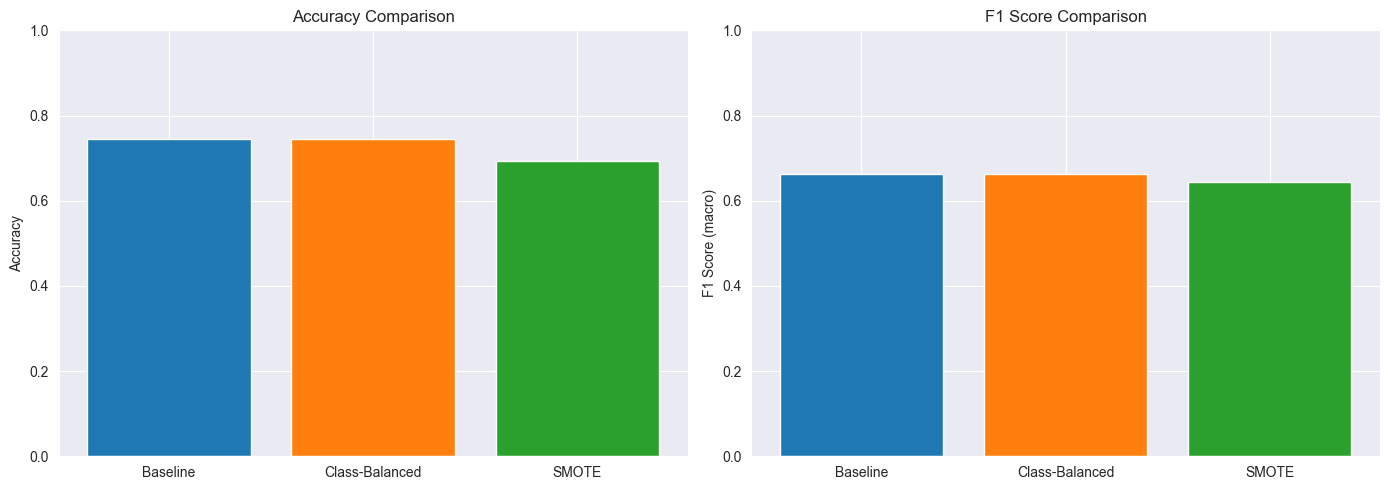

In [11]:
# Summary comparison
print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Approach': ['Baseline MLP', 'Class-Balanced MLP', 'SMOTE MLP'],
    'Accuracy': [acc_baseline, acc_balanced, acc_smote],
    'F1 Score (macro)': [f1_baseline, f1_balanced, f1_smote]
})

print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

approaches = ['Baseline', 'Class-Balanced', 'SMOTE']
accuracies = [acc_baseline, acc_balanced, acc_smote]
f1_scores = [f1_baseline, f1_balanced, f1_smote]

axes[0].bar(approaches, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim([0, 1])

axes[1].bar(approaches, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('F1 Score (macro)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('mlp_comparison.png', dpi=300)
plt.show()

## 8. Confusion Matrices

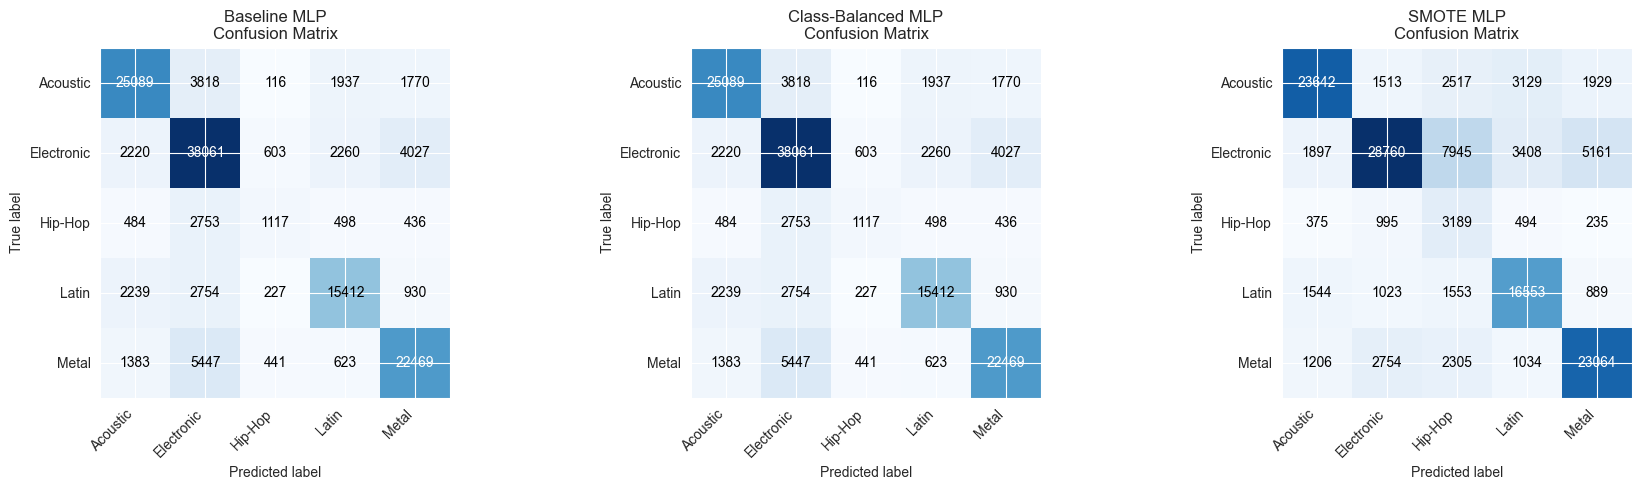

In [12]:
# Create confusion matrices for all three approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Baseline MLP', y_pred_baseline_labels),
    ('Class-Balanced MLP', y_pred_balanced_labels),
    ('SMOTE MLP', y_pred_smote_labels)
]

for idx, (title, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test_labels, y_pred, labels=class_names)
    
    im = axes[idx].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[idx].set_title(f'{title}\nConfusion Matrix')
    
    tick_marks = np.arange(len(class_names))
    axes[idx].set_xticks(tick_marks)
    axes[idx].set_xticklabels(class_names, rotation=45, ha='right')
    axes[idx].set_yticks(tick_marks)
    axes[idx].set_yticklabels(class_names)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, format(cm[i, j], 'd'),
                          ha="center", va="center",
                          color="white" if cm[i, j] > thresh else "black")
    
    axes[idx].set_ylabel('True label')
    axes[idx].set_xlabel('Predicted label')

plt.tight_layout()
plt.savefig('mlp_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()